## <b><font color='darkblue'>Preface</font></b>
Sample code to use [**`yfinance`**](https://github.com/ranaroussi/yfinance) to query below information:
- Stock price of certain name or id in Taiwan stock market
- Stocks that increased over 5% today
- Stocks with dividend yield over 5%
- Top gaining Taiwan stocks this week
- Show historical price trend for TSMC

### <b><font color='darkgreen'>Install packages</font></b>

```bash
$ uv add yfinance
```

In [11]:
!uv pip list | grep yfinance

Using Python 3.12.3 environment at: /mnt/sdb/Gitrepos/finance_agent/.venv
yfinance                  1.3.0


### <b><font color='darkgreen'>Import Libraries</font></b>

In [12]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

## <b><font color='darkblue'>Usages</font></b>
Here we are going to introduce usages of target package.

### <b><font color='darkgreen'>1. Query Stock Price by Taiwan Stock ID</font></b>
Example:
- TSMC → `2330.TW`
- ETF 0050 → `0050.TW`

In [13]:
%%time
symbol = "2330.TW"

ticker = yf.Ticker(symbol)

CPU times: user 4.63 ms, sys: 6.18 ms, total: 10.8 ms
Wall time: 8.86 ms


In [14]:
# Get latest market price
info = ticker.info

print("Symbol:", symbol)
print("Company:", info.get("longName"))
print("Current Price:", info.get("currentPrice"))
print("Previous Close:", info.get("previousClose"))
print("Market Cap:", info.get("marketCap"))

Symbol: 2330.TW
Company: Taiwan Semiconductor Manufacturing Company Limited
Current Price: 2290.0
Previous Close: 2310.0
Market Cap: 59384277237760


### <b><font color='darkgreen'>2. Find Stocks That Increased Over 5% Today</font></b>
Yahoo Finance does not provide all Taiwan stocks automatically. You usually need a predefined Taiwan stock list.

Example stock list:

In [15]:
taiwan_stocks = [
    "2330.TW",  # TSMC
    "2317.TW",  # Hon Hai
    "2454.TW",  # MediaTek
    "2303.TW",  # UMC
    "0050.TW"   # ETF
]

In [16]:
results = []

for symbol in taiwan_stocks:
    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info

        current_price = info.get("currentPrice")
        prev_close = info.get("previousClose")

        if current_price and prev_close:
            increase_pct = (
                (current_price - prev_close)
                / prev_close
            ) * 100

            if increase_pct > 5:
                results.append({
                    "symbol": symbol,
                    "increase_pct": round(increase_pct, 2)
                })

    except Exception as e:
        print(f"Error processing {symbol}: {e}")

print("Stocks increased over 5% today:")

for r in results:
    print(r)

Stocks increased over 5% today:
{'symbol': '2454.TW', 'increase_pct': 6.14}


### <b><font color='darkgreen'>3. Find Stocks With Dividend Yield Over 5%</font></b>
[**`Dividend Yield`**](https://zh.wikipedia.org/zh-tw/%E7%8F%BE%E9%87%91%E6%AE%96%E5%88%A9%E7%8E%87) (殖利率)
> 現金殖利率（英語：Dividend yield）的定義是 [**每股股利**](https://zh.wikipedia.org/wiki/%E8%82%A1%E6%81%AF)（現金股利）除以 [**每股股價**]( https://zh.wikipedia.org/wiki/%E8%82%A1%E5%83%B9)，通常以百分比表示。
> 
> 例：現金股利為1元，股價20元，則現金殖利率為5%；若來年配息仍為1元，股價已至25元，則現金殖利率降為4%。
> 
> 若股票的現金殖利率大於 [**定期存款**](https://zh.wikipedia.org/wiki/%E5%AE%9A%E6%9C%9F%E5%AD%98%E6%AC%BE) 的利率，一般會稱為 [**定存概念股**](https://zh.wikipedia.org/zh-tw/%E7%8F%BE%E9%87%91%E6%AE%96%E5%88%A9%E7%8E%87#cite_note-%E5%AD%AB%E4%BC%8A%E5%BB%B72011-3)。

In [19]:
symbol = "2330.TW"

ticker = yf.Ticker(symbol)

info = ticker.info

current_price = info.get("currentPrice")

# Annual dividend per share
annual_dividend = info.get("dividendRate")

print("Current Price:", current_price)
print("Annual Dividend:", annual_dividend)

if current_price and annual_dividend:
    dividend_yield = (
        annual_dividend / current_price
    ) * 100

    print(
        f"Calculated Dividend Yield: "
        f"{dividend_yield:.2f}%"
    )

Current Price: 2290.0
Annual Dividend: 24.0
Calculated Dividend Yield: 1.05%


### <b><font color='darkgreen'>4. Find Top Gaining Taiwan Stocks This Week</font></b>
his example calculates 7-day return:

In [21]:
taiwan_stocks = [
    "2330.TW",
    "2317.TW",
    "2454.TW",
    "2303.TW",
    "0050.TW"
]

results = []

for symbol in taiwan_stocks:
    try:
        ticker = yf.Ticker(symbol)

        hist = ticker.history(period="7d")

        if len(hist) >= 2:
            start_price = hist["Close"].iloc[0]
            end_price = hist["Close"].iloc[-1]

            weekly_return = (
                (end_price - start_price)
                / start_price
            ) * 100

            results.append({
                "symbol": symbol,
                "weekly_return_pct": float(round(weekly_return, 2))
            })

    except Exception as e:
        print(f"Error processing {symbol}: {e}")

# Sort descending
results = sorted(
    results,
    key=lambda x: x["weekly_return_pct"],
    reverse=True
)

print("Top gaining Taiwan stocks this week:")

for r in results:
    print(r)

Top gaining Taiwan stocks this week:
{'symbol': '2454.TW', 'weekly_return_pct': 40.97}
{'symbol': '2303.TW', 'weekly_return_pct': 22.55}
{'symbol': '2317.TW', 'weekly_return_pct': 11.11}
{'symbol': '0050.TW', 'weekly_return_pct': 6.89}
{'symbol': '2330.TW', 'weekly_return_pct': 5.05}


### <b><font color='darkgreen'>5. Show Historical Price Trend for TSMC</font></b>
Example using `pandas` plotting.

                                 Open        High         Low       Close  \
Date                                                                        
2025-05-08 00:00:00+08:00  919.282699  925.194485  904.503235  904.503235   
2025-05-09 00:00:00+08:00  924.209151  935.047424  920.267960  935.047424   
2025-05-12 00:00:00+08:00  939.973978  947.856359  938.003382  942.929871   
2025-05-13 00:00:00+08:00  975.444669  975.444669  954.753418  954.753418   
2025-05-14 00:00:00+08:00  975.444699  984.312378  973.474103  984.312378   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-05-08 00:00:00+08:00  27985917        0.0           0.0  
2025-05-09 00:00:00+08:00  36383573        0.0           0.0  
2025-05-12 00:00:00+08:00  23402547        0.0           0.0  
2025-05-13 00:00:00+08:00  38047856        0.0           0.0  
2025-05-14 00:00:00+08:00  40475123        0.0           0.0  


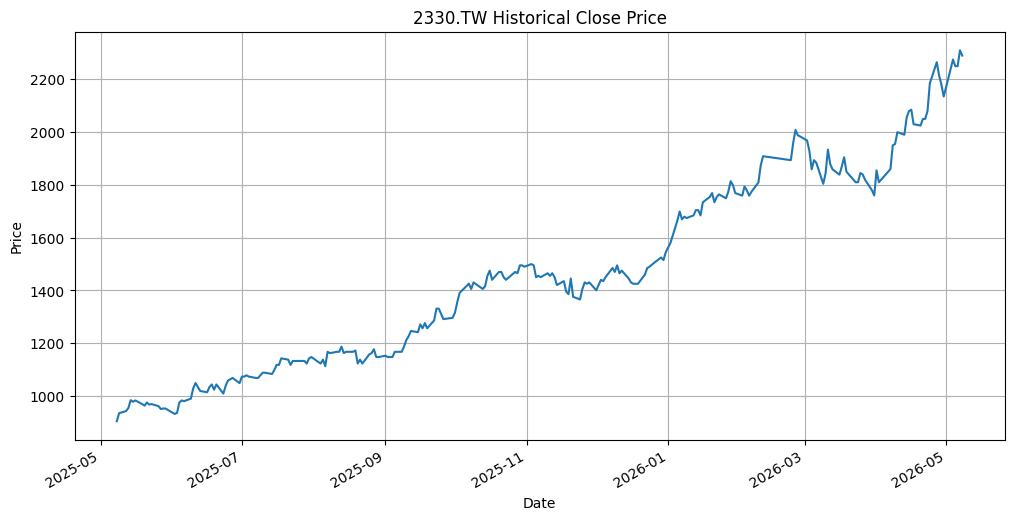

In [23]:
import yfinance as yf
import matplotlib.pyplot as plt

symbol = "2330.TW"

ticker = yf.Ticker(symbol)

# 1 year history
hist = ticker.history(period="1y")

print(hist.head())

# Plot close price trend
hist["Close"].plot(
    figsize=(12, 6),
    title=f"{symbol} Historical Close Price"
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

### <b><font color='darkgreen'>6. Recommended Improvement for Your Agent</font></b>
Instead of directly calling `ticker.info` repeatedly, you should:

- Cache stock metadata locally
- Cache historical prices into SQLite/PostgreSQL
- Run screening queries against local DB
- Use `yfinance` only for synchronization

This design will:

- Improve performance
- Reduce Yahoo Finance requests
- Avoid rate limiting
- Make analytics much faster

### <b><font color='darkgreen'>7. Suggested Helper Wrapper</font></b>
You can encapsulate `yfinance` into your provider layer.

Example:

In [24]:
import yfinance as yf

class YahooFinanceProvider:

    def get_stock_info(self, symbol: str):
        ticker = yf.Ticker(symbol)
        return ticker.info

    def get_history(
        self,
        symbol: str,
        period: str = "1y"
    ):
        ticker = yf.Ticker(symbol)
        return ticker.history(period=period)

Usage:

In [25]:
provider = YahooFinanceProvider()

hist = provider.get_history("2330.TW")

print(hist.tail())

                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-05-04 00:00:00+08:00  2200.0  2285.0  2195.0  2275.0  38390062   
2026-05-05 00:00:00+08:00  2250.0  2270.0  2240.0  2250.0  21625279   
2026-05-06 00:00:00+08:00  2250.0  2285.0  2240.0  2250.0  31918664   
2026-05-07 00:00:00+08:00  2335.0  2345.0  2310.0  2310.0  35034517   
2026-05-08 00:00:00+08:00  2300.0  2310.0  2265.0  2290.0  27102571   

                           Dividends  Stock Splits  
Date                                                
2026-05-04 00:00:00+08:00        0.0           0.0  
2026-05-05 00:00:00+08:00        0.0           0.0  
2026-05-06 00:00:00+08:00        0.0           0.0  
2026-05-07 00:00:00+08:00        0.0           0.0  
2026-05-08 00:00:00+08:00        0.0           0.0  


### <b><font color='darkgreen'>8. Recommended Next Step</font></b>
For your `finance_agent`, the next recommended implementation order is:

1. Build provider abstraction
2. Build SQLite schema
3. Implement sync service
4. Implement screening queries
5. Add ADK tools
6. Add natural language intent parsing
7. Add LLM reasoning